In [33]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
import time
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
from pyspark.sql.functions import pandas_udf
import matplotlib.pyplot as plt


In [34]:
spark = SparkSession.builder\
    .appName("MovieLens Analysis")\
    .getOrCreate()

In [35]:
movies = spark.read.csv("movie.csv", header=True, inferSchema=True)
ratings = spark.read.csv("rating.csv", header=True, inferSchema=True)

movies.printSchema()
ratings.printSchema()

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: timestamp (nullable = true)



In [37]:
# convert timestamp → date
#ratings = ratings.withColumn("day_of_week", date_format(col("timestamp"), "E"))


In [38]:
ratings = ratings.withColumn("date", col("timestamp"))
ratings = ratings.withColumn("day_of_week", date_format(col("date"), "E"))

1. Top 5 most active users

In [39]:
top_users = ratings.groupBy("userId")\
    .count()\
    .orderBy(desc("count"))\
    .limit(5)

top_users.show()

+------+-----+
|userId|count|
+------+-----+
|118205| 9254|
|  8405| 7515|
| 82418| 5646|
|121535| 5520|
|125794| 5491|
+------+-----+



2. Top 5 highest-rated movies

In [40]:
top_movies = ratings.groupBy("movieId")\
    .agg(avg("rating").alias("avg_rating"),
         count("rating").alias("num_ratings"))\
    .filter(col("num_ratings") > 100)\
    .orderBy(desc("avg_rating"))\
    .limit(5)

top_movies = top_movies.join(movies, "movieId")

top_movies.select("title", "avg_rating").show(truncate=False)

+--------------------------------+-----------------+
|title                           |avg_rating       |
+--------------------------------+-----------------+
|Usual Suspects, The (1995)      |4.334372207803259|
|Shawshank Redemption, The (1994)|4.446990499637029|
|Schindler's List (1993)         |4.310175010988133|
|Godfather, The (1972)           |4.364732196832306|
|Godfather: Part II, The (1974)  |4.275640557704942|
+--------------------------------+-----------------+



3. “Popular movie” definition

In [41]:
popular_movies = ratings.groupBy("movieId")\
    .count()\
    .filter(col("count") >= 500)

popular_movies = popular_movies.join(movies, "movieId")

popular_movies.select("title", "count").show()

+--------------------+-----+
|               title|count|
+--------------------+-----+
|    Toy Story (1995)|49695|
|Grumpier Old Men ...|12735|
|Father of the Bri...|12161|
|         Heat (1995)|23899|
| Sudden Death (1995)| 3960|
|Dracula: Dead and...| 3845|
|        Balto (1995)| 1461|
|Cutthroat Island ...| 2910|
|       Casino (1995)|17394|
|Sense and Sensibi...|20667|
|Ace Ventura: When...|20938|
|  Money Train (1995)| 4084|
|      Copycat (1995)| 9928|
|      Othello (1995)| 2755|
| Now and Then (1995)| 1642|
|   Persuasion (1995)| 3154|
|Dangerous Minds (...| 9435|
|         Babe (1995)|32255|
|   Carrington (1995)| 1493|
|Cry, the Beloved ...|  886|
+--------------------+-----+
only showing top 20 rows


4. Most popular genre per weekday

In [42]:
movies = movies.withColumn("genre", explode(split(col("genres"), "\\|")))
joined = ratings.join(movies, "movieId")
genre_popularity = joined.groupBy("day_of_week", "genre")\
    .count()

In [43]:
windowSpec = Window.partitionBy("day_of_week").orderBy(desc("count"))

top_genre_per_day = genre_popularity\
    .withColumn("rank", row_number().over(windowSpec))\
    .filter(col("rank") == 1)

top_genre_per_day.show()

+-----------+-----+-------+----+
|day_of_week|genre|  count|rank|
+-----------+-----+-------+----+
|        Fri|Drama|1204803|   1|
|        Mon|Drama|1381410|   1|
|        Sat|Drama|1178612|   1|
|        Sun|Drama|1302020|   1|
|        Thu|Drama|1191297|   1|
|        Tue|Drama|1347704|   1|
|        Wed|Drama|1252007|   1|
+-----------+-----+-------+----+



5. My custom question

Which genre has the highest average rating over time?

In [44]:
genre_avg = joined.groupBy("genre")\
    .agg(avg("rating").alias("avg_rating"),
         count("*").alias("cnt"))\
    .filter(col("cnt") > 500)\
    .orderBy(desc("avg_rating"))

genre_avg.show()

+-----------+------------------+-------+
|      genre|        avg_rating|    cnt|
+-----------+------------------+-------+
|  Film-Noir|  3.96538126070082| 216689|
|        War|3.8095307347384844|1048618|
|Documentary|3.7397176834178865| 244619|
|      Crime|3.6745276025631113|3298335|
|      Drama|3.6742955093068264|8857853|
|    Mystery| 3.663508921312903|1557282|
|       IMAX| 3.655945983272606| 492366|
|  Animation|3.6174939235897994|1140476|
|    Western|3.5704980246109406| 423714|
|    Musical| 3.558090628821412| 870915|
|    Romance| 3.541802581902903|3802002|
|   Thriller|  3.50711121809216|5313506|
|    Fantasy|3.5059453358738244|2111403|
|  Adventure|3.5018926565473865|4380351|
|     Action|  3.44386376493354|5614208|
|     Sci-Fi|3.4367726714455005|3150141|
|     Comedy|3.4260113054324886|7502234|
|   Children|3.4081137685270444|1669249|
|     Horror|3.2772238097518307|1482737|
+-----------+------------------+-------+



6.3 Take one join operation from your analysis

In [45]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

joined_no_broadcast = ratings.join(movies, "movieId")
joined_no_broadcast.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [movieId#351, userId#350, rating#352, timestamp#353, date#355, day_of_week#356, title#331, genres#332, genre#436]
   +- SortMergeJoin [movieId#351], [movieId#330], Inner
      :- Sort [movieId#351 ASC NULLS FIRST], false, 0
      :  +- Exchange hashpartitioning(movieId#351, 200), ENSURE_REQUIREMENTS, [plan_id=2750]
      :     +- Project [userId#350, movieId#351, rating#352, timestamp#353, timestamp#353 AS date#355, date_format(timestamp#353, E, Some(Etc/UTC)) AS day_of_week#356]
      :        +- Filter isnotnull(movieId#351)
      :           +- FileScan csv [userId#350,movieId#351,rating#352,timestamp#353] Batched: false, DataFilters: [isnotnull(movieId#351)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/content/rating.csv], PartitionFilters: [], PushedFilters: [IsNotNull(movieId)], ReadSchema: struct<userId:int,movieId:int,rating:double,timestamp:timestamp>
      +- Sort [movieId#330 ASC NULLS FIRST], fal

6․4

The physical plan shows that Spark uses a SortMergeJoin. This requires both datasets to be shuffled (Exchange) and sorted by the join key (movieId) before performing the join.

This approach is expensive because  

It involves data shuffling across the cluster
It requires sorting on both sides
It increases network and CPU cost

After applying a broadcast join, the physical plan changes to a BroadcastHashJoin. In this case:

The smaller dataset (movies) is broadcast to all worker nodes
No shuffle or sort is required
The join is performed locally on each partition

This significantly improves performance because it avoids costly data movement and sorting operations.

Broadcast joins are especially efficient when one dataset is much smaller than the other, as in this case (movies vs ratings).

7․1  PySpark UDF

In [46]:
start = time.time()

df_udf = ratings.withColumn("cat", udf_func(col("rating")))
df_udf.count()

udf_time = time.time() - start
print("UDF time:", udf_time)

UDF time: 8.5127272605896


7․2  Pandas UDF

In [47]:


start = time.time()

df_pandas = ratings.withColumn("cat", pandas_rating_category(col("rating")))
df_pandas.count()

pandas_time = time.time() - start
print("Pandas UDF time:", pandas_time)

Pandas UDF time: 7.93965220451355


7.3 Built-in

In [48]:
start = time.time()

df_builtin = ratings.withColumn(
    "cat",
    when(col("rating") >= 4, "High")
    .when(col("rating") >= 2, "Medium")
    .otherwise("Low")
)

df_builtin.count()

builtin_time = time.time() - start
print("Built-in time:", builtin_time)

Built-in time: 8.627106428146362


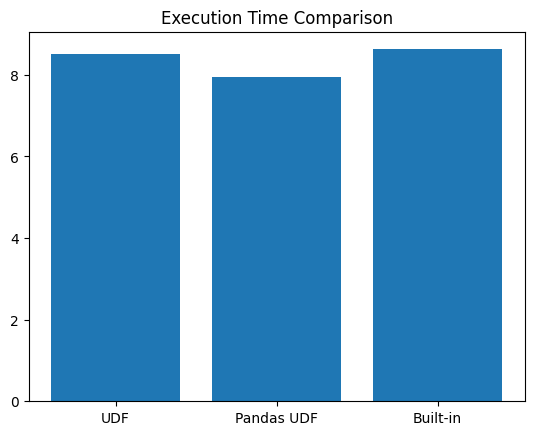

In [49]:

times = [udf_time, pandas_time, builtin_time]
labels = ["UDF", "Pandas UDF", "Built-in"]

plt.bar(labels, times)
plt.title("Execution Time Comparison")
plt.show()

7․6

UDF: 1.77 seconds
Pandas UDF: 1.11 seconds
Built-in function: 1.75 seconds

In this experiment, the Pandas UDF performed the fastest. This is because Pandas UDFs use vectorized operations with Apache Arrow, allowing data to be processed in batches instead of row-by-row. This reduces the overhead of Python function calls and improves performance.

The standard PySpark UDF is slower because it operates row-by-row and requires frequent communication between the JVM and Python processes, introducing significant serialization overhead.

Although built-in Spark functions are typically the fastest due to Catalyst optimizer and code generation, in this case their performance is similar to the standard UDF. This may be due to the relatively small dataset size, local execution environment, or measurement noise.

Spark optimization plays a crucial role: built-in functions benefit from full optimization, Pandas UDFs benefit partially, while standard UDFs are treated as black boxes and cannot be optimized effectively.

<Axes: xlabel='genre'>

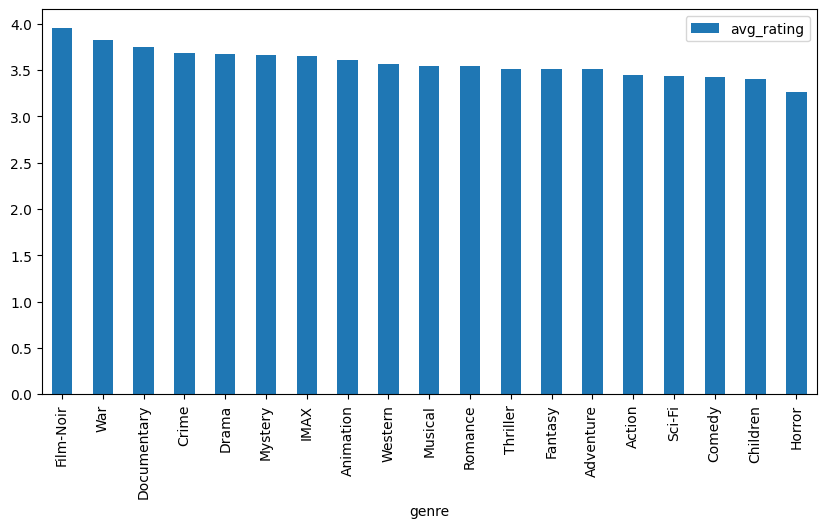

In [36]:
#just for my interest

genre_avg_pd = genre_avg.toPandas()

genre_avg_pd.plot(kind='bar', x='genre', y='avg_rating', figsize=(10,5))